# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

path = os.getcwd()
df = pd.read_csv( path+"//dmt_data.csv", index_col=False )

In [2]:
display( df.head() )

,DMT-Previous Experiences,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
0,1,0.669,0.036,0.152,0.009,0.004,0.100,0.465,0.060,0.278,0.022,0.018,0.126,0.040,0.040,0.030,0.029,0.021,0.018,3.874
1,1,0.403,0.085,0.351,0.009,0.007,0.116,0.234,0.100,0.431,0.035,0.031,0.140,0.055,0.066,0.016,0.006,0.014,0.018,4.348
2,1,0.234,0.127,0.355,0.043,0.028,0.184,0.117,0.103,0.538,0.023,0.013,0.177,0.079,0.082,0.012,0.024,0.047,0.014,4.191
3,1,0.284,0.044,0.414,0.011,0.006,0.211,0.063,0.069,0.577,0.039,0.037,0.185,0.036,0.014,0.035,0.046,0.042,0.009,3.970
4,0,0.425,0.051,0.314,0.024,0.023,0.133,0.203,0.060,0.474,0.045,0.040,0.148,0.001,0.004,0.023,0.008,0.029,0.000,4.559


In [3]:
y = df['DMT-Previous Experiences']
X = df.drop( columns='DMT-Previous Experiences' )

# Correlations

,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
Point-Biserial Correlation,0.203537,0.221899,-0.219093,-0.190525,-0.271034,-0.065712,-0.073884,0.286512,0.091009,-0.064476,-0.070584,-0.120048,0.513154,0.504135,0.252994,0.508922,0.439731,0.514933,0.115095


,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
p-value,0.29888,0.256433,0.262649,0.331483,0.162997,0.739721,0.708669,0.139368,0.645103,0.744456,0.721155,0.542868,0.005229,0.00623,0.193967,0.00568,0.019208,0.005049,0.559758


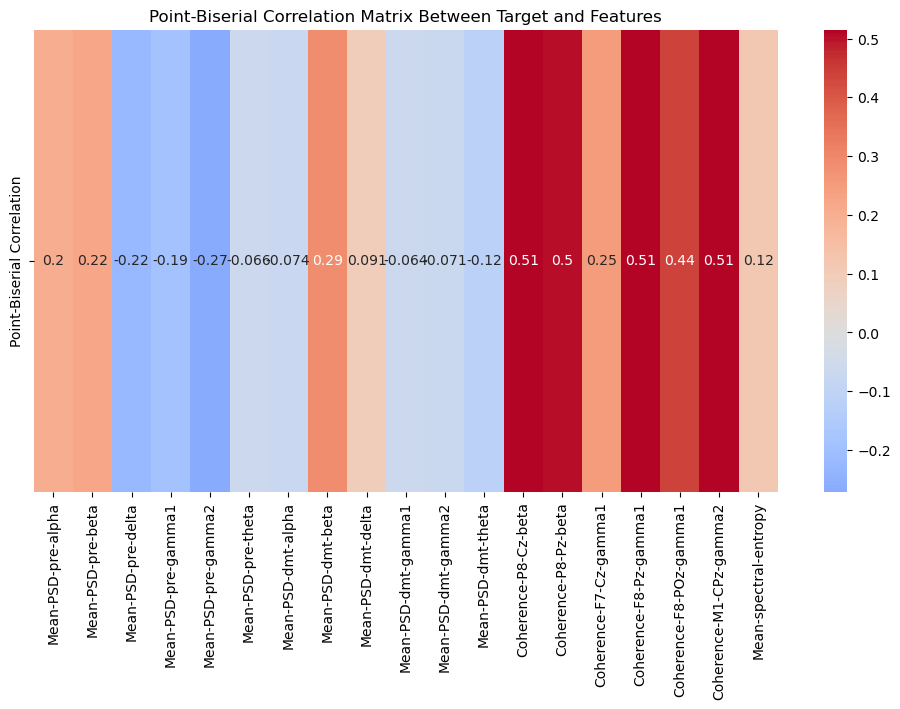

In [4]:
from scipy.stats import pointbiserialr
import seaborn as sns

correlations = {}
p_values = {}

for col in X.columns:
    corr, p_value = pointbiserialr( y, df[col] )
    correlations[col] = corr
    p_values[col] = p_value

corr = pd.DataFrame( correlations, index=['Point-Biserial Correlation'] )
corr_p_value = pd.DataFrame( p_values, index=['p-value'] )
display( corr )
display( corr_p_value )

plt.figure( figsize=(12, 6) )
sns.heatmap( corr, annot=True, cmap='coolwarm', center=0 )
plt.title( 'Point-Biserial Correlation Matrix Between Target and Features' )
plt.show()


# 1. Logistic Regression

# 1.1 Model Selection and Hyperparameter Tuning

In [5]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_logreg = Pipeline([
    ( 'scaler', StandardScaler() ),
    ('logistic_regression', LogisticRegression( solver='liblinear', random_state= 42 ) )
])

loo = LeaveOneOut()

param_grid_logreg = {
    'logistic_regression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logistic_regression__penalty': ['l1', 'l2']
    }

grid_search_logreg = GridSearchCV(
    estimator = pipe_logreg,
    param_grid = param_grid_logreg,
    cv = loo,
    scoring = 'accuracy',
    n_jobs = -1
    )

grid_search_logreg.fit( X.values, y.values )
best_params_logreg = grid_search_logreg.best_params_
print( f"Best parameters: {best_params_logreg}" )

best_logreg = grid_search_logreg.best_estimator_

Best parameters: {'logistic_regression__C': 1, 'logistic_regression__penalty': 'l2'}


In [6]:
print( best_logreg.named_steps )

{'scaler': StandardScaler(), 'logistic_regression': LogisticRegression(C=1, random_state=42, solver='liblinear')}


# 1.2 Evaluate model performance

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_logreg = []
y_pred_logreg = []
y_proba_logreg = []

for train_index, test_index in loo.split( X.values ):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.values[train_index], y.values[test_index]
    best_logreg.fit( X_train, y_train )
    pred = best_logreg.predict( X_test )
    prob = best_logreg.predict_proba( X_test )[:, 1]
    y_true_logreg.append( y_test[0] )
    y_pred_logreg.append( pred[0] )
    y_proba_logreg.append( prob[0] )

confusion = confusion_matrix( y_true_logreg, y_pred_logreg )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_true_logreg, y_pred_logreg, target_names = ['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[ 9  2]
 [ 1 16]]

               precision    recall  f1-score   support

     one-time       0.90      0.82      0.86        11
multiple-time       0.89      0.94      0.91        17

     accuracy                           0.89        28
    macro avg       0.89      0.88      0.89        28
 weighted avg       0.89      0.89      0.89        28



# 1.3 Visualize results

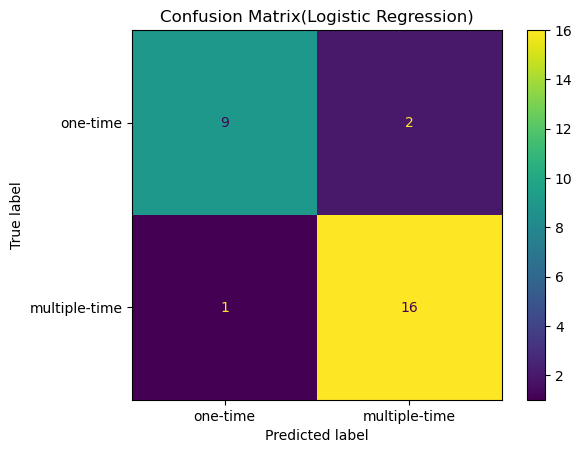

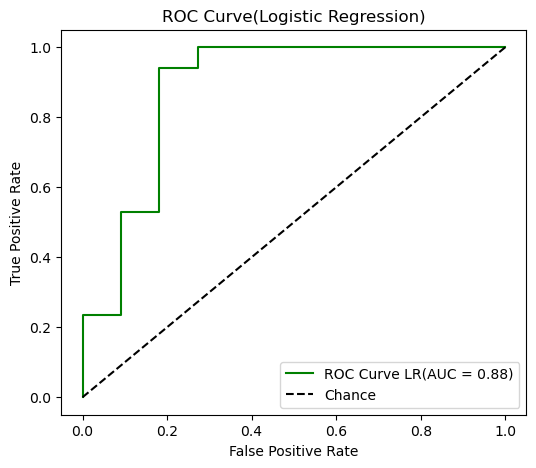

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(  y_true_logreg, y_pred_logreg, display_labels = ['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(Logistic Regression)' )
plt.show()

fpr_lr, tpr_lr, thresholds_lr = roc_curve( y_true_logreg, y_proba_logreg )
roc_auc_lr = auc( fpr_lr, tpr_lr )

# RocCurveDisplay.from_predictions( y_true_logreg, y_pred_logreg, name = 'Logistic Regression', plot_chance_level = True )
plt.figure( figsize=( 6, 5 ) )
plt.plot( fpr_lr, tpr_lr, label = f'ROC Curve LR(AUC = {roc_auc_lr:.2f})', color = 'green' )
plt.plot( [0, 1], [0, 1], 'k--', label = 'Chance' )
plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.title( 'ROC Curve(Logistic Regression)' )
plt.legend( loc = 'lower right' )
plt.show()



# 1.4 Feature Importance Analysis

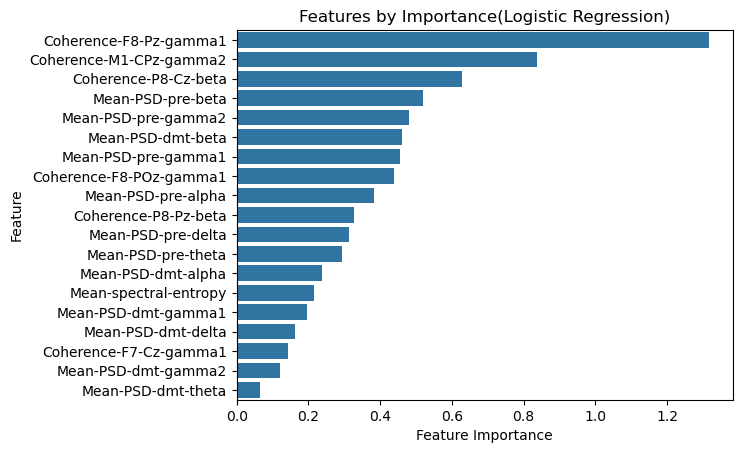

In [10]:
import seaborn as sns

coefficients = best_logreg.named_steps['logistic_regression'].coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(Logistic Regression)' )
plt.xlabel( "Feature Importance" )
plt.show()

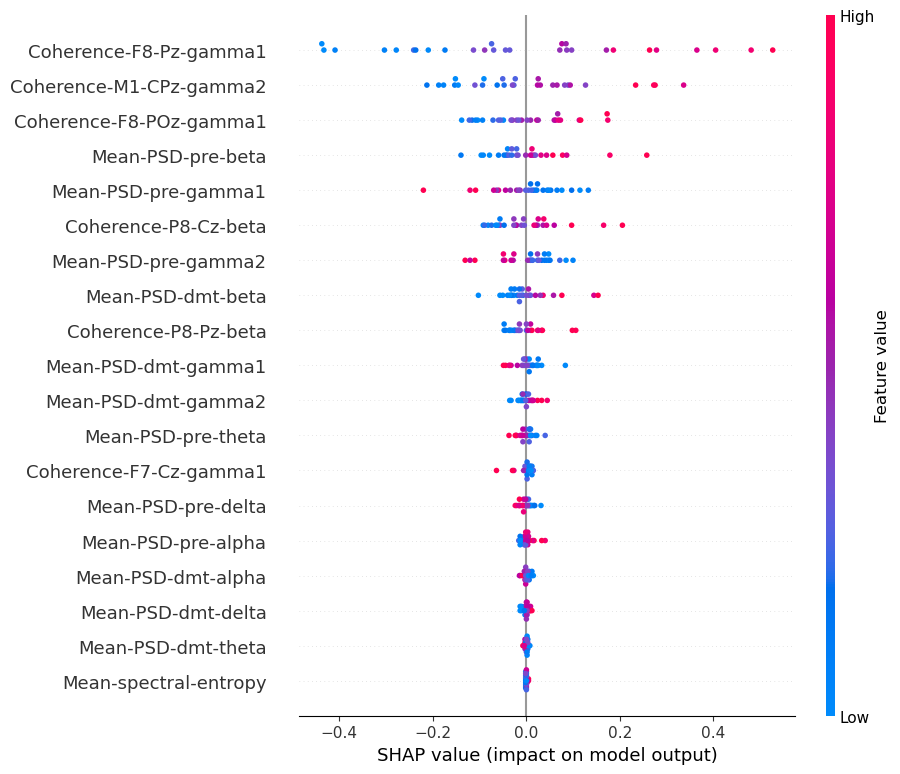

In [15]:
# SHAP
import shap

scaler = StandardScaler()
X_scaled = scaler.fit_transform( X )
exp_lr = shap.Explainer( best_logreg.predict, X_scaled, feature_names=X.columns )
shap_lr = exp_lr( X_scaled )
shap.plots.beeswarm( shap_lr, max_display=20 )

# 1.5 Statistical Significance Testing

In [10]:
# from sklearn.model_selection import permutation_test_score

# # Perform permutation test
# score, perm_scores, pvalue = permutation_test_score(
#     best_log_reg, X_train_scaled, y_train, 
#     scoring="accuracy", cv=5, n_permutations=1000
# )

# print(f"Model accuracy: {score:.4f}")
# print(f"Permutation accuracy scores mean: {perm_scores.mean():.4f}")
# print(f"P-value: {pvalue:.4f}")

# # Plot permutation test results
# plt.figure(figsize=(10, 6))
# plt.hist(perm_scores, bins=20, edgecolor='black')
# plt.axvline(score, color='red', linestyle='--', label=f'Accuracy = {score:.4f}')
# plt.xlabel('Accuracy')
# plt.ylabel('Frequency')
# plt.title('Permutation Test Results')
# plt.legend()
# plt.show()

# 2. Support Vector Machine(SVM)

# 2.1 Model Selection and Hyperparameter Tuning

In [16]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

pipe_svm = Pipeline([
    ( 'scaler', StandardScaler() ),
    ( 'svm', SVC( probability = True, random_state = 42 ) )
])

loo = LeaveOneOut()

param_grid_svm = [
    {'svm__kernel': ['linear'], 'svm__C': [0.01, 0.1, 1, 10, 100]},
    {'svm__kernel': ['rbf'], 'svm__C': [0.01, 0.1, 1, 10, 100], 'svm__gamma': [0.01, 0.1, 1, 10]}
]

grid_search_svm = GridSearchCV(
    estimator = pipe_svm,
    param_grid = param_grid_svm,
    cv = loo,
    scoring = 'accuracy',
    n_jobs = -1
    )

grid_search_svm.fit( X.values, y.values )
best_params_svm = grid_search_svm.best_params_
print( f"Best parameters: {best_params_svm}" )

best_svm = grid_search_svm.best_estimator_

Best parameters: {'svm__C': 1, 'svm__kernel': 'linear'}


# 2.2 Model Evaluation

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_svm = []
y_pred_svm = []
y_proba_svm = []

for train_index, test_index in loo.split( X.values ):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.values[train_index], y.values[test_index]
    best_svm.fit( X_train, y_train )
    pred = best_svm.predict( X_test )
    prob = best_svm.predict_proba( X_test )[:, 1]
    y_true_svm.append( y_test[0] )
    y_pred_svm.append( pred[0] )
    y_proba_svm.append( prob[0] )

confusion = confusion_matrix( y_true_svm, y_pred_svm )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_true_svm, y_pred_svm, target_names = ['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[ 8  3]
 [ 0 17]]

               precision    recall  f1-score   support

     one-time       1.00      0.73      0.84        11
multiple-time       0.85      1.00      0.92        17

     accuracy                           0.89        28
    macro avg       0.93      0.86      0.88        28
 weighted avg       0.91      0.89      0.89        28



# 2.3 Visualizaton of Results

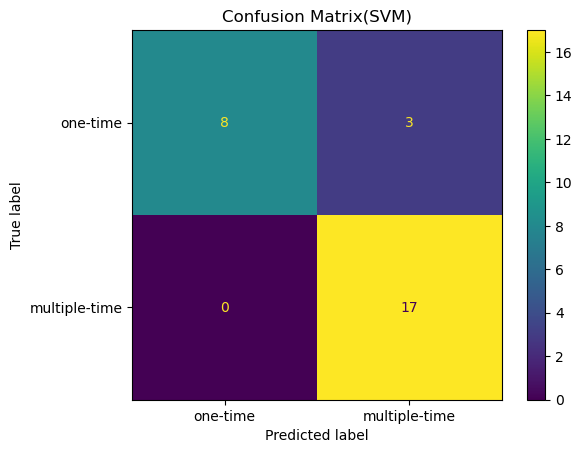

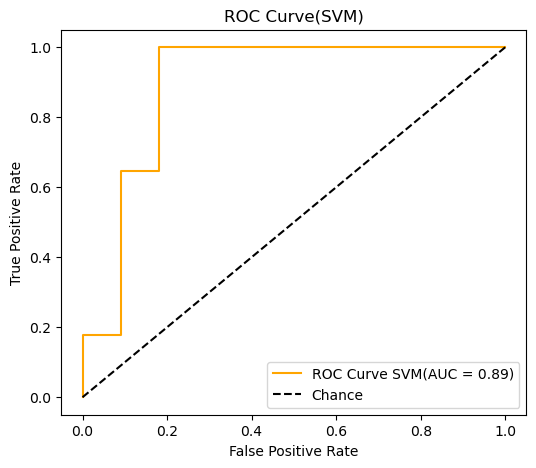

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(  y_true_svm, y_pred_svm, display_labels = ['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(SVM)' )
plt.show()

fpr_svm, tpr_svm, thresholds_svm = roc_curve( y_true_svm, y_proba_svm )
roc_auc_svm = auc( fpr_svm, tpr_svm )

# RocCurveDisplay.from_predictions( y_true_svm, y_pred_svm, name = 'SVM', plot_chance_level = True )
plt.figure( figsize=( 6, 5 ) )
plt.plot( fpr_svm, tpr_svm, label = f'ROC Curve SVM(AUC = {roc_auc_svm:.2f})', color = 'orange' )
plt.plot( [0, 1], [0, 1], 'k--', label = 'Chance' )
plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.title( 'ROC Curve(SVM)' )
plt.legend( loc = 'lower right' )
plt.show()

# 2.4 Feature Importance Analysis

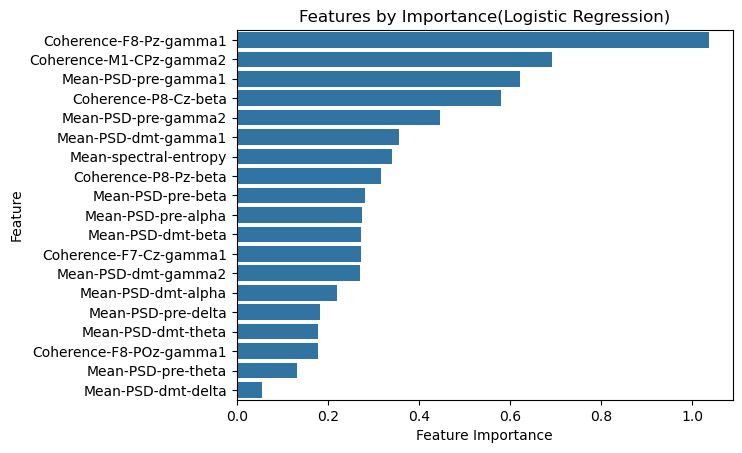

In [20]:
import seaborn as sns

coefficients = best_svm.named_steps['svm'].coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(Logistic Regression)' )
plt.xlabel( "Feature Importance" )
plt.show()

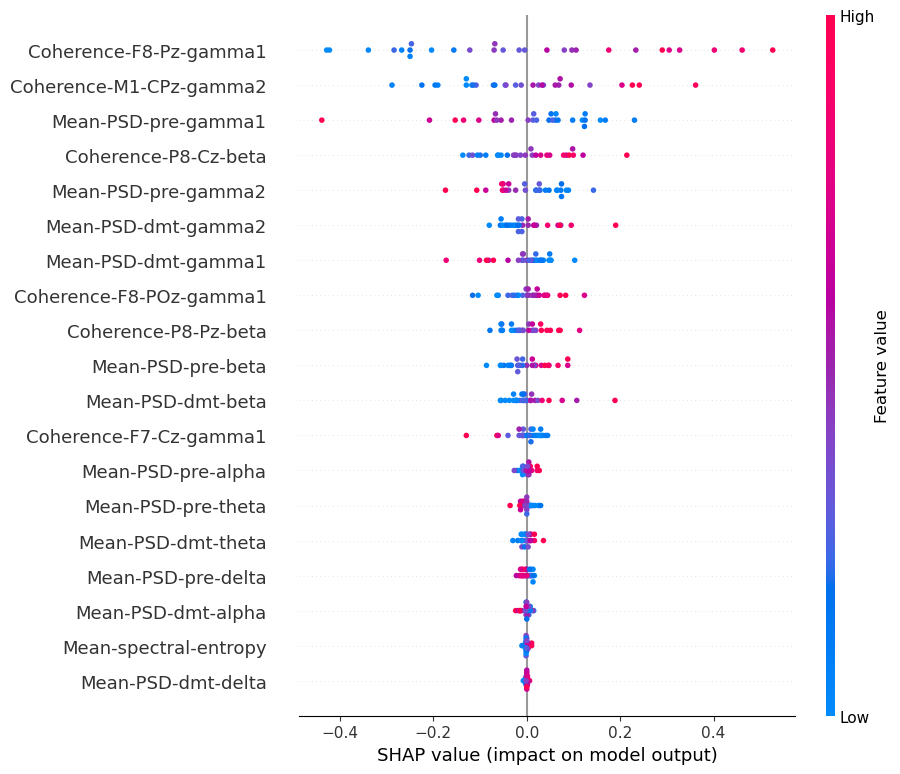

In [21]:
# SHAP
exp_svm = shap.Explainer( best_svm.predict, X_scaled, feature_names=X.columns )
shap_svm = exp_svm( X_scaled )
shap.plots.beeswarm( shap_svm, max_display=20 )

# 3. Random Forest

# 3.1 Model Selection and Hyperparameter Tuning

In [22]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipe_rf = Pipeline([
    ( 'scaler', StandardScaler() ),
    ('random_forest',RandomForestClassifier( random_state= 42 ) )
])

loo = LeaveOneOut()

param_grid_rf = {
    'random_forest__n_estimators': [10, 50, 100, 200],
    'random_forest__max_depth': [None, 5, 10, 20],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 4]
    }

grid_search_rf = GridSearchCV(
    estimator = pipe_rf,
    param_grid = param_grid_rf,
    cv = loo,
    scoring = 'accuracy',
    n_jobs = -1
    )

grid_search_rf.fit( X.values, y.values )
best_params_rf = grid_search_rf.best_params_
print( f"Best parameters: {best_params_rf}" )

best_rf = grid_search_rf.best_estimator_


Best parameters: {'random_forest__max_depth': None, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}


# 3.2 Model Evaluation

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_rf = []
y_pred_rf = []
y_proba_rf = []

for train_index, test_index in loo.split( X.values ):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.values[train_index], y.values[test_index]
    best_rf.fit( X_train, y_train )
    pred = best_rf.predict( X_test )
    prob = best_rf.predict_proba( X_test )[:, 1]
    y_true_rf.append( y_test[0] )
    y_pred_rf.append( pred[0] )
    y_proba_rf.append( prob[0] )

confusion = confusion_matrix( y_true_rf, y_pred_rf )
print( f"Confusion matrix: \n{confusion}" )
print( classification_report( y_true_rf, y_pred_rf, target_names = ['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[ 9  2]
 [ 0 17]]
               precision    recall  f1-score   support

     one-time       1.00      0.82      0.90        11
multiple-time       0.89      1.00      0.94        17

     accuracy                           0.93        28
    macro avg       0.95      0.91      0.92        28
 weighted avg       0.94      0.93      0.93        28



# 3.3 Visualization of Results

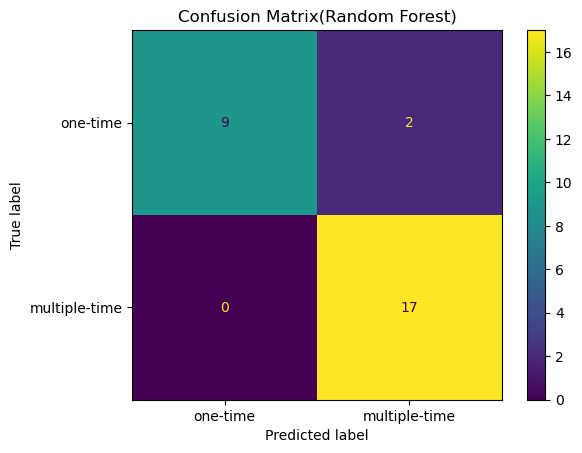

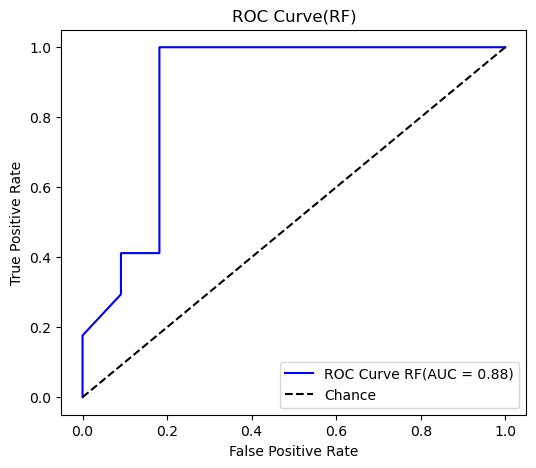

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(  y_true_rf, y_pred_rf, display_labels = ['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(Random Forest)' )
plt.show()

fpr_rf, tpr_rf, thresholds_rf = roc_curve( y_true_rf, y_proba_rf )
roc_auc_rf = auc( fpr_rf, tpr_rf )

plt.figure( figsize=( 6, 5 ) )
plt.plot( fpr_rf, tpr_rf, label = f'ROC Curve RF(AUC = {roc_auc_rf:.2f})', color = 'blue' )
plt.plot( [0, 1], [0, 1], 'k--', label = 'Chance' )
plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.title( 'ROC Curve(RF)' )
plt.legend( loc = 'lower right' )
plt.show()

# 3.4 Feature Importance Analysis

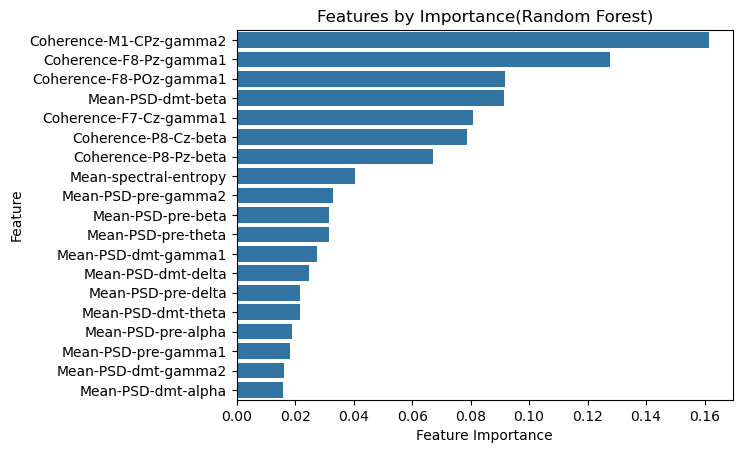

In [25]:
importances = best_rf.named_steps['random_forest'].feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame( {"Feature": feature_names, "Feature Importance": importances} )
feat_imp_df = feat_imp_df.sort_values( 'Feature Importance', ascending=False )

sns.barplot( y='Feature', x='Feature Importance', data=feat_imp_df )
plt.title( 'Features by Importance(Random Forest)' )
plt.show()

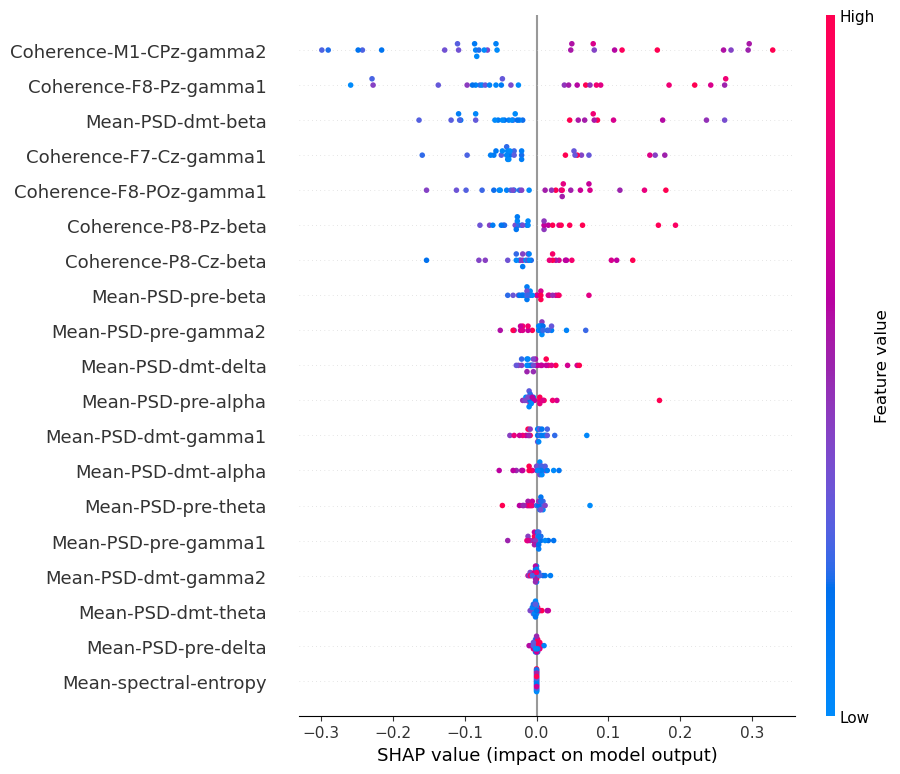

In [26]:
# SHAP
exp_rf = shap.Explainer( best_rf.predict, X_scaled, feature_names=X.columns )
shap_rf = exp_rf( X_scaled )
shap.plots.beeswarm( shap_rf, max_display=20 )

# 4. GradientBoosting

# 4.1 Model Selection and Hyperparameter Tuning

In [27]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

pipe_gb = Pipeline([
    ( 'scaler', StandardScaler() ),
    ( 'gb',GradientBoostingClassifier( random_state= 42 ) )
])

loo = LeaveOneOut()

param_grid_gb = {
    'gb__n_estimators': [10, 50, 100, 200],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__max_depth': [None, 3, 5, 10],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4]
}

grid_search_gb = GridSearchCV(
    estimator = pipe_gb,
    param_grid = param_grid_gb,
    cv = loo,
    scoring='accuracy',
    n_jobs = -1
)

grid_search_gb.fit( X.values, y.values )
best_params_gb = grid_search_gb.best_params_
print( f"Best parameters: {best_params_gb}" )

best_gb = grid_search_gb.best_estimator_

Best parameters: {'gb__learning_rate': 0.01, 'gb__max_depth': None, 'gb__min_samples_leaf': 1, 'gb__min_samples_split': 10, 'gb__n_estimators': 50}


# 4.2 Model Evaluation

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_gb = []
y_pred_gb = []
y_proba_gb = []

for train_index, test_index in loo.split( X.values ):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.values[train_index], y.values[test_index]
    best_gb.fit( X_train, y_train )
    pred = best_gb.predict( X_test )
    prob = best_gb.predict_proba( X_test )[:, 1]
    y_true_gb.append( y_test[0] )
    y_pred_gb.append( pred[0] )
    y_proba_gb.append( prob[0] )

confusion = confusion_matrix( y_true_gb, y_pred_gb )
print( f"Confusion matrix: \n{confusion}" )
print( classification_report( y_true_gb, y_pred_gb, target_names = ['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[ 9  2]
 [ 3 14]]
               precision    recall  f1-score   support

     one-time       0.75      0.82      0.78        11
multiple-time       0.88      0.82      0.85        17

     accuracy                           0.82        28
    macro avg       0.81      0.82      0.82        28
 weighted avg       0.83      0.82      0.82        28



# 4.3 Visualization of Results

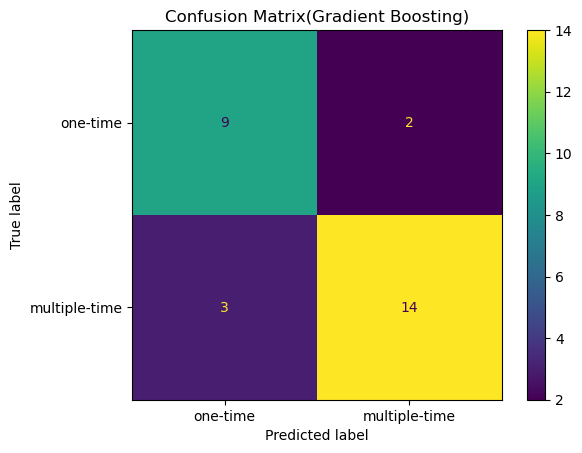

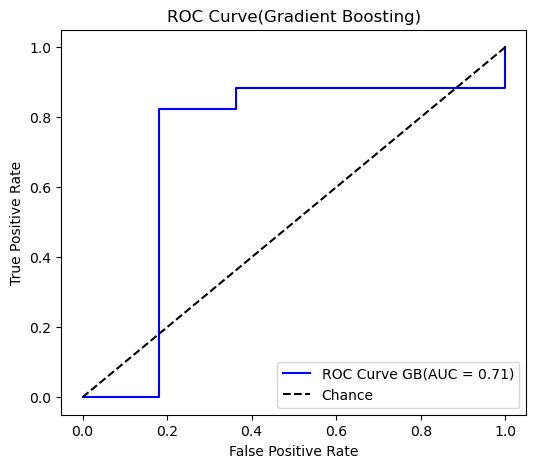

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(  y_true_gb, y_pred_gb, display_labels = ['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(Gradient Boosting)' )
plt.show()

fpr_gb, tpr_gb, thresholds_gb = roc_curve( y_true_gb, y_proba_gb )
roc_auc_gb = auc( fpr_gb, tpr_gb )

plt.figure( figsize=( 6, 5 ) )
plt.plot( fpr_gb, tpr_gb, label = f'ROC Curve GB(AUC = {roc_auc_gb:.2f})', color = 'blue' )
plt.plot( [0, 1], [0, 1], 'k--', label = 'Chance' )
plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.title( 'ROC Curve(Gradient Boosting)' )
plt.legend( loc = 'lower right' )
plt.show()

# 4.4 Feature Importance Analysis

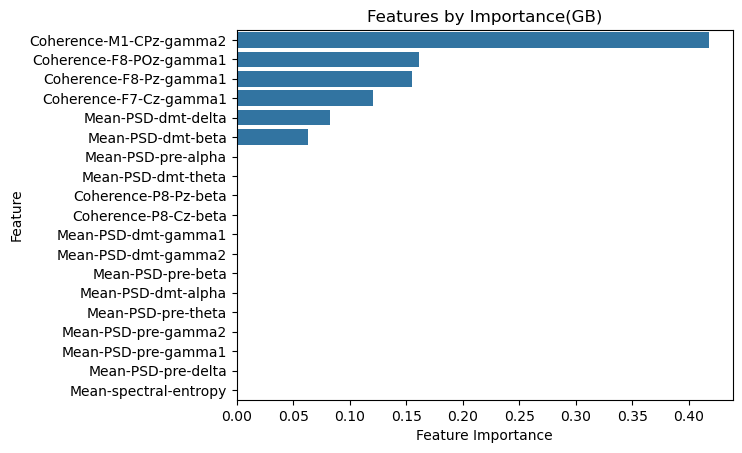

In [30]:
importances_gb = best_gb.named_steps['gb'].feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame( {"Feature": feature_names, "Feature Importance": importances_gb} )
feat_imp_df = feat_imp_df.sort_values( 'Feature Importance', ascending=False )

sns.barplot( y='Feature', x='Feature Importance', data=feat_imp_df )
plt.title( 'Features by Importance(GB)' )
plt.show()

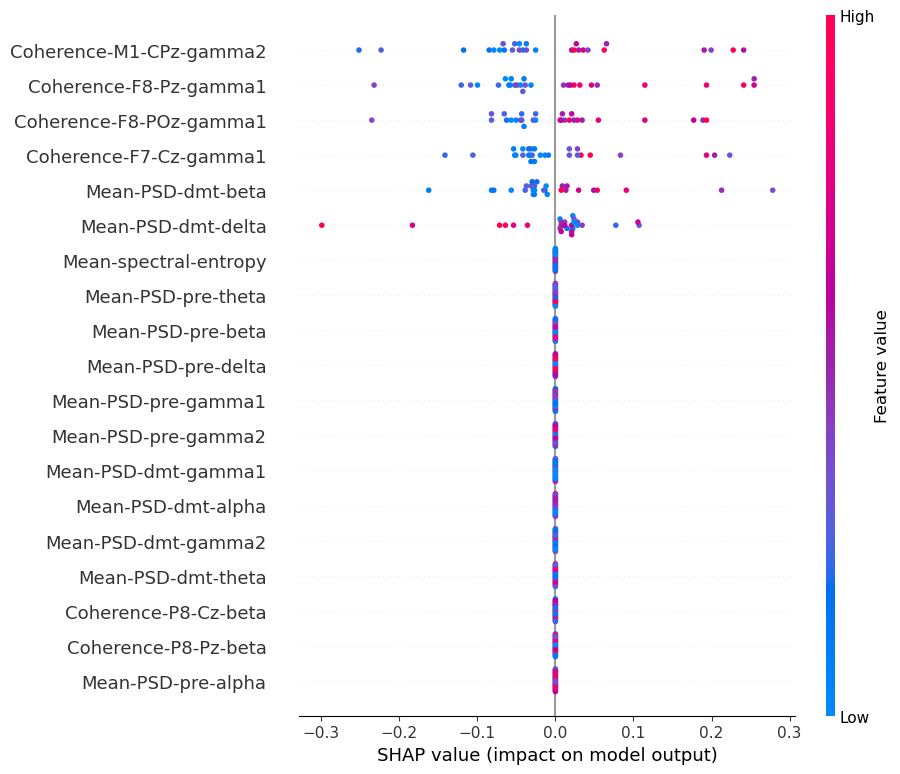

In [31]:
# SHAP
exp_gb = shap.Explainer( best_gb.predict, X_scaled, feature_names=X.columns )
shap_gb = exp_gb( X_scaled )
shap.plots.beeswarm( shap_gb, max_display=20 )